In [ ]:
import pandas as pd
import numpy as np 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data
import torch
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

df = pd.read_csv('D:\\IDE Repo\\Dl-net\\data\\casme2-preprocessed-v2\\train.csv')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}") # type: ignore

In [ ]:
feature_columns = ['aspect_ratio', 'brightness',  'contrast', 'sharpness', 'edge_density', 'entropy', 'noise']

target_column = 'class' 

X = df[feature_columns].values      # shape: [N, 7]
y = df[target_column].values        # shape: [N,]

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes mapping:")
for index, class_name in enumerate(encoder.classes_):
    print(f"{class_name} : {index}")

y_level = np.unique(y_encoded)
print("\nUnique encoded levels:", y_level)

Classes mapping:
angry : 0
disgust : 1
fear : 2
happy : 3
neutral : 4
sad : 5
surprise : 6

Unique encoded levels: [0 1 2 3 4 5 6]


# Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
k = 7 # For facial patches/landmarks in CASME II, keep k small (e.g., 4 to 8)
nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

edge_index_list = []

# Build undirected graph edges
for i in range(indices.shape[0]):
    for j in indices[i][1:]:  # skip indices[i][0] because it is i itself
        edge_index_list.append([i, j])
        edge_index_list.append([j, i])  # make graph undirected

edge_index = np.array(edge_index_list).T  # shape: [2, E]

print(f"\nGraph successfully built with k={k}")
print(f"Edge index shape: {edge_index.shape}")
print(f"Encoded target shape (y_level): {np.unique(y_encoded).shape}")


Graph successfully built with k=7
Edge index shape: (2, 190610)
Encoded target shape (y_level): (7,)


# Convert to PyTorch Geometric Data object

In [ ]:
x = torch.tensor(X_scaled, dtype=torch.float32)       # [N, F]
y_tensor = torch.tensor(y_encoded, dtype=torch.long)  # [N]
edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, E]
data = Data(x=x, edge_index=edge_index_tensor, y=y_tensor)

print(data)

Data(x=[13615, 7], edge_index=[2, 190610], y=[13615])


In [ ]:
data_cpu = data.cpu()

# Convert to NetworkX (undirected for nicer layout)
G = to_networkx(data_cpu, to_undirected=True, to_multi=True) 

palette = [
    'tab:blue', 
    'tab:orange', 
    'tab:green', 
    'tab:red', 
    'tab:purple', 
    'tab:brown', 
    'tab:pink'
]
 
# Node colors based on emotions Level 
y = data_cpu.y.numpy()
color_map = [palette[label] for label in y]

# Spring layout (force-directed)
pos = nx.spring_layout(G, k=0.1, iterations=50)

plt.figure(figsize=(8, 8))
nx.draw(
    G, pos,
    node_color=color_map,
    node_size=10,
    edge_color='black',
    linewidths=0
)
plt.axis('off')
plt.title("Patient Similarity Graph (colored by emotions Level)")
plt.show()

C:\Users\Sad Bin Siddique\AppData\Local\Temp\ipykernel_26196\703610182.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


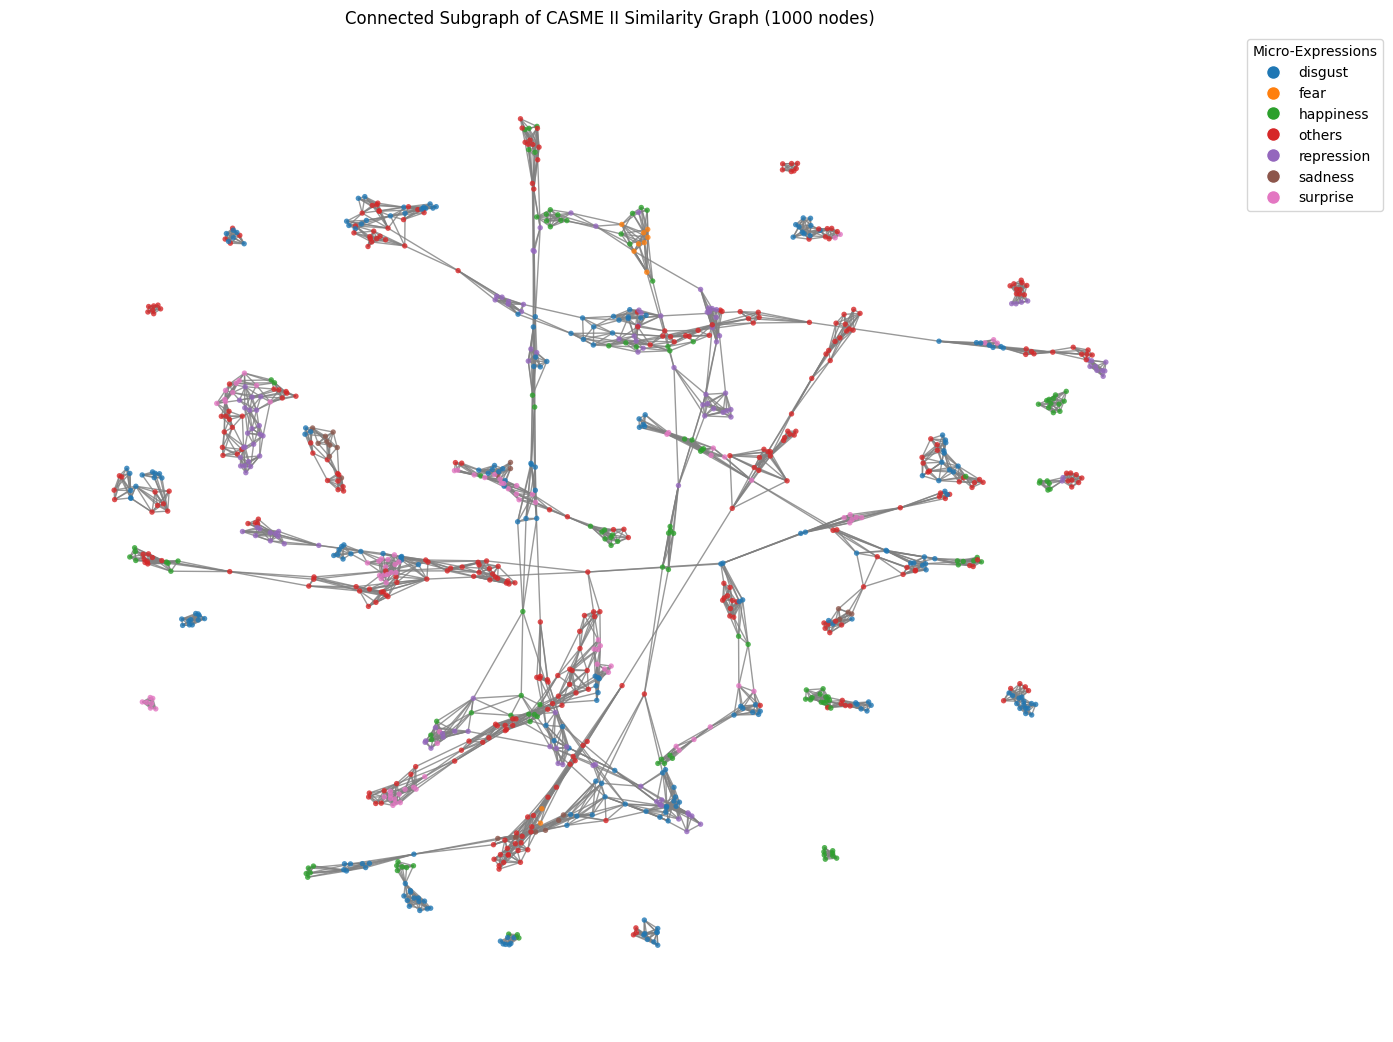

In [ ]:
num_nodes_to_plot = 500

# 1. Randomly sample the features and labels of 500 nodes
subset_idx = torch.randperm(data_cpu.num_nodes)[:num_nodes_to_plot]
x_sub = data_cpu.x[subset_idx].numpy()
y_sub = data_cpu.y[subset_idx].numpy()

# 2. RECOMPUTE the k-NN edges specifically for this subset so they connect  
nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(x_sub)
distances, indices = nbrs.kneighbors(x_sub)

edge_index_list = []
for i in range(indices.shape[0]):
    for j in indices[i][1:]:
        edge_index_list.append([i, j])
        edge_index_list.append([j, i])

edge_index_sub = torch.tensor(np.array(edge_index_list).T, dtype=torch.long)

# 3. Create a new Data object with the connected subset
sub_data = Data(x=torch.tensor(x_sub), edge_index=edge_index_sub, y=torch.tensor(y_sub))
G_sub = to_networkx(sub_data, to_undirected=True)

# 4. Plotting setup
casme_classes = ['disgust', 'fear', 'happiness', 'others', 'repression', 'sadness', 'surprise']
palette = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink']
color_map_sub = [palette[label] for label in y_sub]

# Note: spring_layout is very slow for 2500 nodes. 
# Lowering 'k' to 0.05 helps pull dense clusters apart slightly.
pos_sub = nx.spring_layout(G_sub, k=0.05, iterations=30) 

plt.figure(figsize=(12, 10))
nx.draw(
    G_sub, pos_sub,
    node_color=color_map_sub,
    node_size=15,
    edge_color='gray',
    alpha=0.8,
    linewidths=0
)

# Custom Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=casme_classes[i],
           markerfacecolor=palette[i], markersize=10)
    for i in range(len(casme_classes))
]
plt.legend(handles=legend_elements, title="Micro-Expressions", loc='upper right', bbox_to_anchor=(1.15, 1))

plt.axis('off')
plt.title(f"Connected Subgraph of CASME II Similarity Graph ({num_nodes_to_plot} nodes)")
plt.tight_layout()
plt.show()

## Graph Property

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import networkx as nx

X = df[feature_columns].values      # shape: [N, F]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 6  # For facial patches/landmarks in CASME II, keep k small (e.g., 4 to 8)

nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

edges = []
N = len(X_scaled)

for i in range(N):
    for j in indices[i][1:]:
        edges.append((i, j))
        edges.append((j, i))

# Create graph
G = nx.Graph()
G.add_edges_from(edges)

# Compute properties
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
degrees = [deg for _, deg in G.degree()]
avg_degree = np.mean(degrees)
density = nx.density(G)
num_components = nx.number_connected_components(G)
clustering = nx.average_clustering(G)

{
    "num_nodes": num_nodes,
    "num_edges": num_edges,
    "average_degree": avg_degree,
    "density": density,
    "connected_components": num_components,
    "average_clustering": clustering
}

{'num_nodes': 17019,
 'num_edges': 67663,
 'average_degree': np.float64(7.951466008578647),
 'density': 0.0004672385714289956,
 'connected_components': 164,
 'average_clustering': 0.5193313877815282}

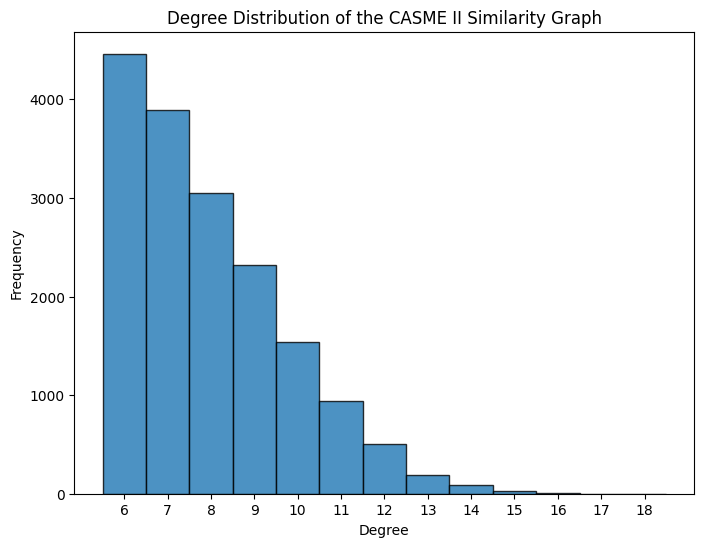

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# 1. Compute Nearest Neighbors
k = 7 # For facial patches/landmarks in CASME II, keep k small (e.g., 4 to 8)
nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

edges = []
N = len(X_scaled)

for i in range(N):
    for j in indices[i][1:]:
        edges.append((i, j))
        edges.append((j, i))  # make undirected

# 2. Create graph
G = nx.Graph()
G.add_edges_from(edges)

# 3. Get Degree sequence
degree_sequence = [d for _, d in G.degree()]

# --- FIXES APPLIED BELOW ---

# Calculate the exact range of degrees to create perfectly sized integer bins
min_degree = min(degree_sequence)
max_degree = max(degree_sequence)
integer_bins = np.arange(min_degree, max_degree + 2) - 0.5 

# Plot degree distribution
plt.figure(figsize=(8, 6))

# Added edgecolor='black' to make the individual bars look much cleaner
plt.hist(degree_sequence, bins=integer_bins, edgecolor='black', alpha=0.8)

plt.xlabel("Degree")
plt.ylabel("Frequency")

# Updated the title to match your specific dataset
plt.title("Degree Distribution of the CASME II Similarity Graph")

# Force the X-axis to only show whole numbers (since you can't have a degree of 6.5)
plt.xticks(range(min_degree, max_degree + 1))

plt.show()

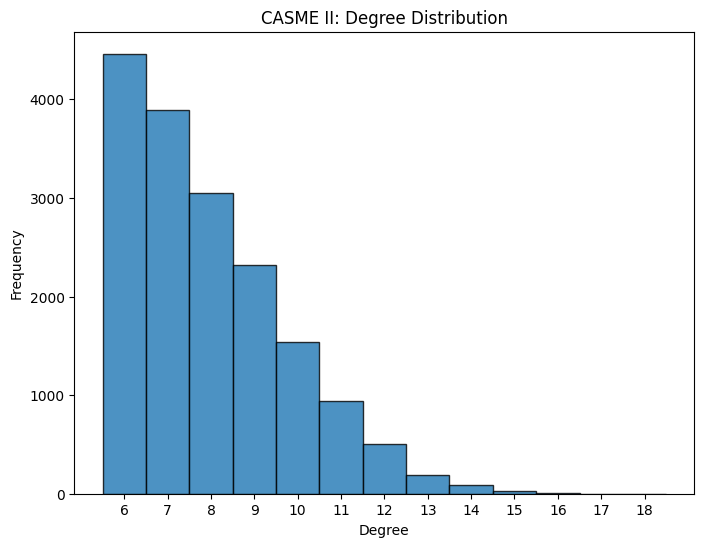

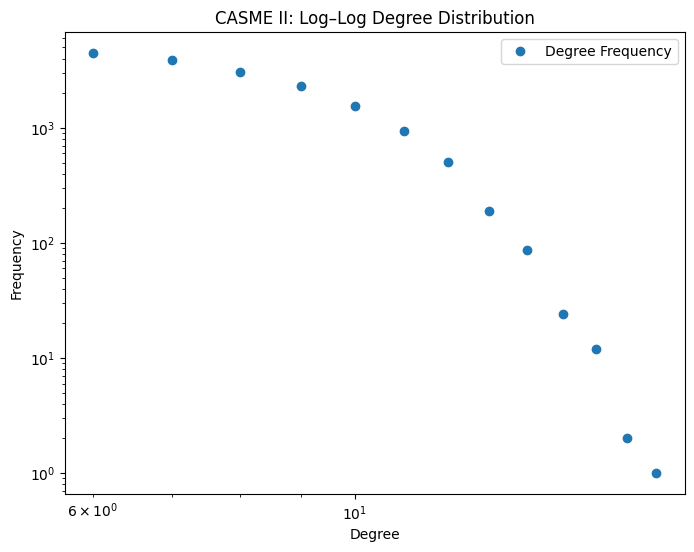

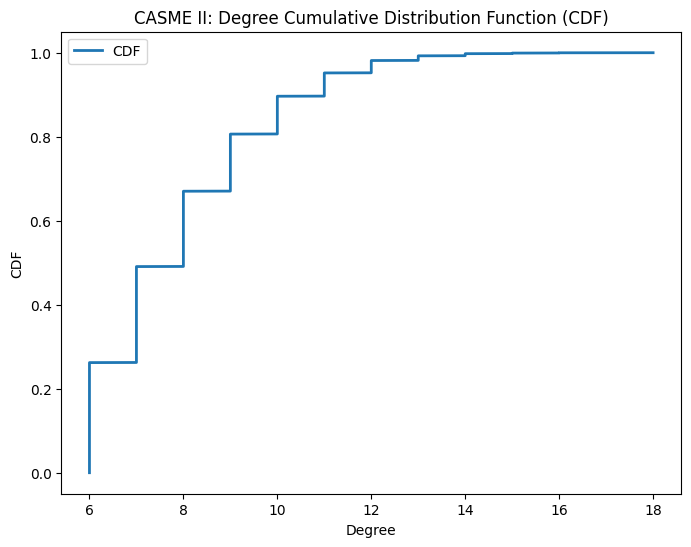

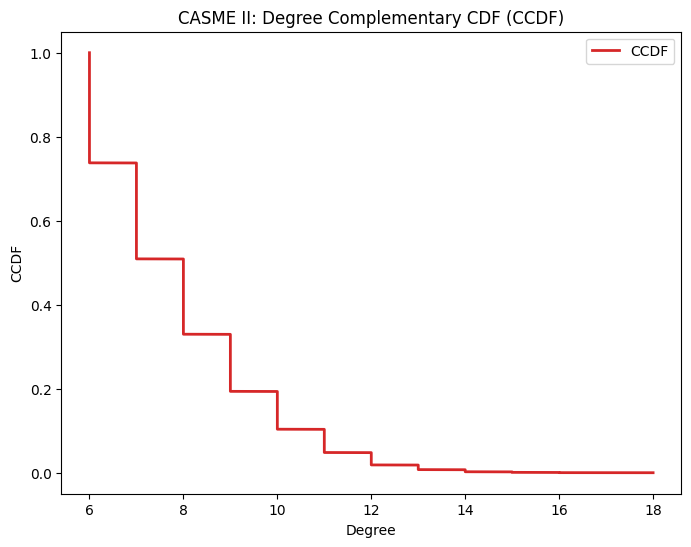

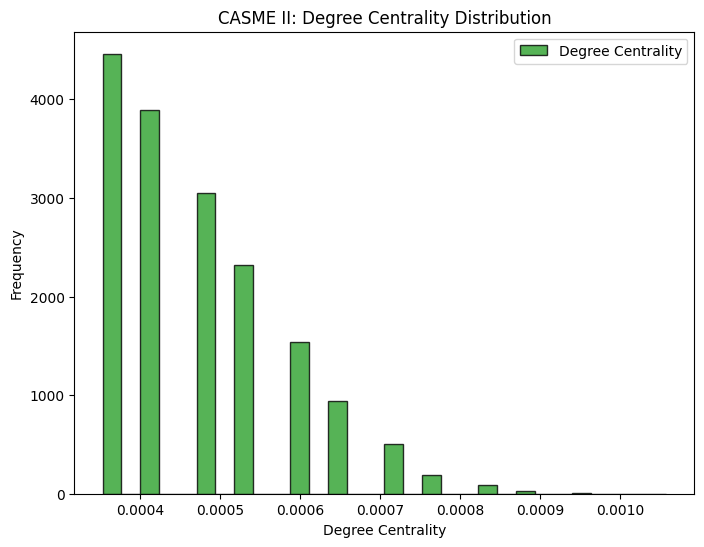

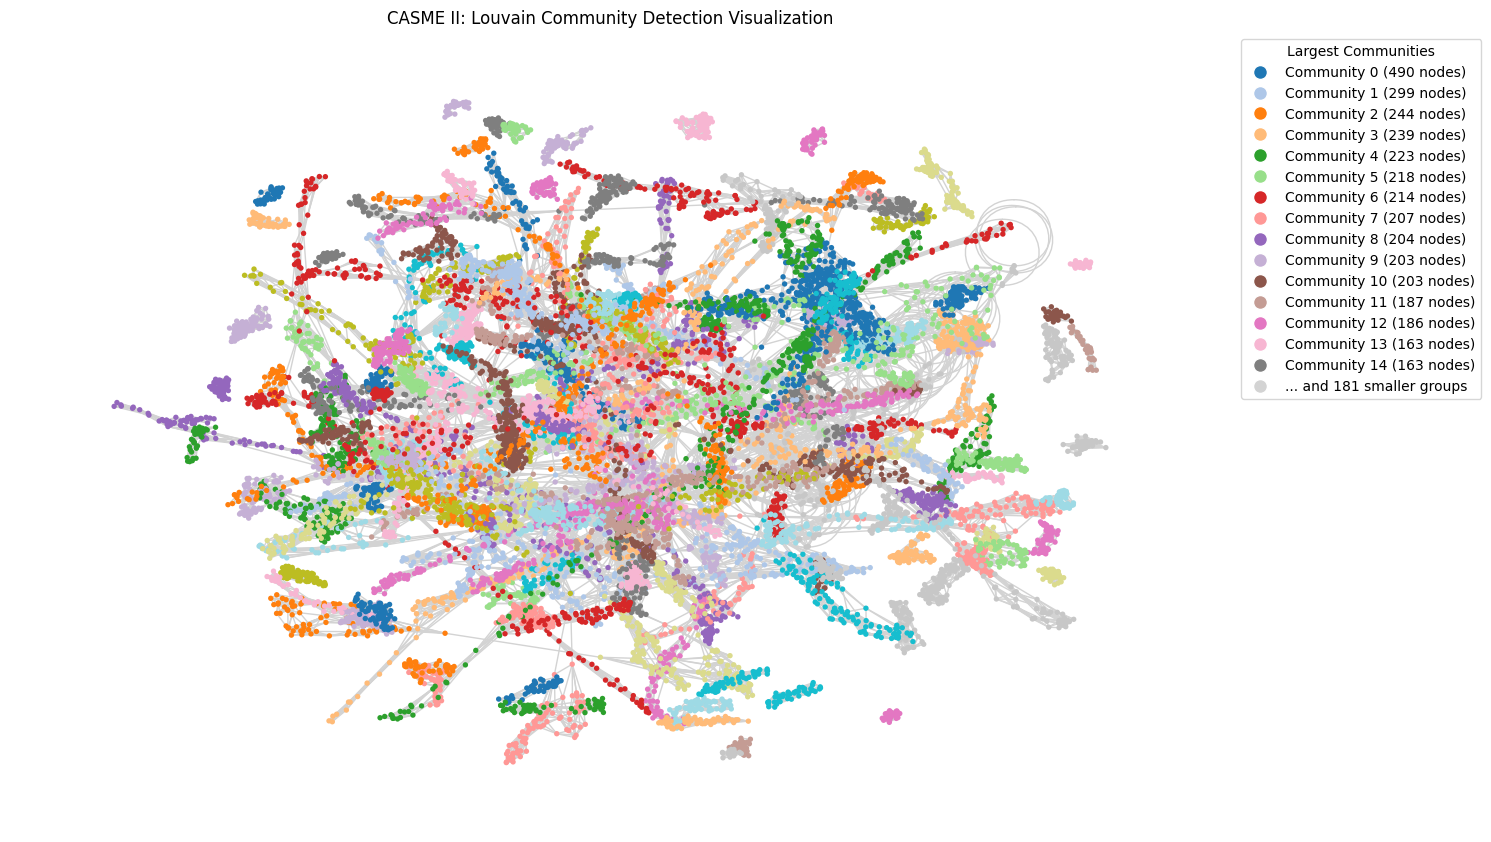

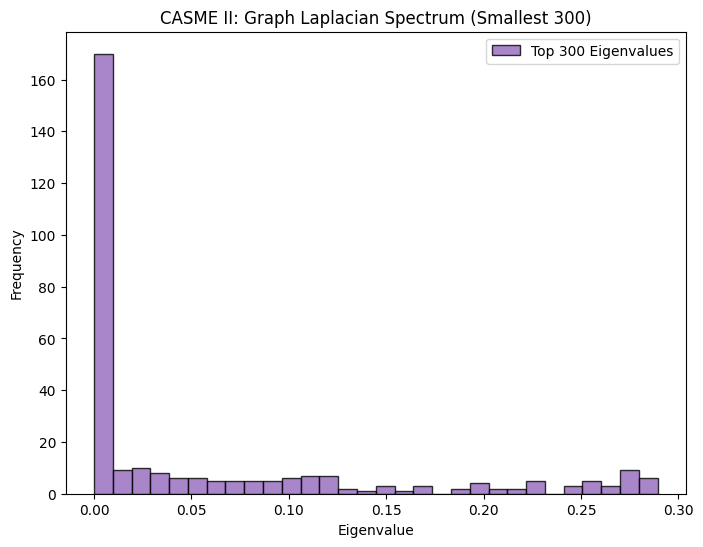

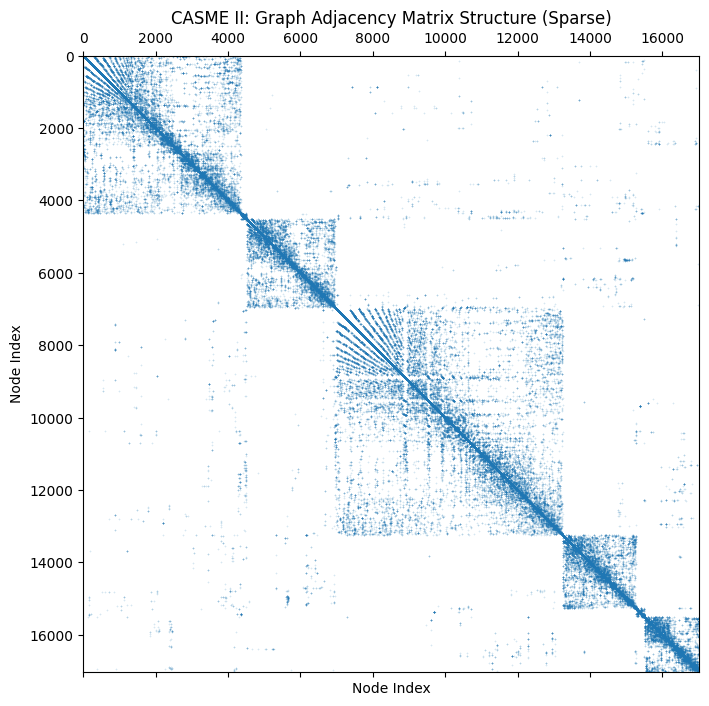

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse.linalg as spsla
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import networkx as nx
from networkx.algorithms import community


k = 7 # Kept small specifically for CASME II facial patches
nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

edges = []
N = len(X_scaled)
for i in range(N):
    for j in indices[i][1:]:
        edges.append((i, j))
        edges.append((j, i))  # make graph undirected

G = nx.Graph()
G.add_edges_from(edges)

# Get degree sequence for later plots
degrees = np.array([d for _, d in G.degree()])


# ===========================================================
# 1. DEGREE DISTRIBUTION (Fixed Integer Bins)
# ===========================================================
min_degree = min(degrees)
max_degree = max(degrees)
integer_bins = np.arange(min_degree, max_degree + 2) - 0.5 

plt.figure(figsize=(8, 6))
plt.hist(degrees, bins=integer_bins, edgecolor='black', alpha=0.8, color='tab:blue')
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("CASME II: Degree Distribution")
plt.xticks(range(int(min_degree), int(max_degree) + 1))
plt.show()

# LOG–LOG DEGREE DISTRIBUTION
plt.figure(figsize=(8, 6))
unique_deg, counts = np.unique(degrees, return_counts=True)
plt.loglog(unique_deg, counts, marker="o", linestyle="none", label="Degree Frequency", color='tab:blue')
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("CASME II: Log–Log Degree Distribution")
plt.legend()
plt.show()


# ===========================================================
# 2. CDF AND CCDF
# ===========================================================
sorted_deg = np.sort(degrees)
cdf = np.arange(1, len(sorted_deg)+1) / len(sorted_deg)
ccdf = 1 - cdf

plt.figure(figsize=(8, 6))
plt.plot(sorted_deg, cdf, label="CDF", color='tab:blue', linewidth=2)
plt.xlabel("Degree")
plt.ylabel("CDF")
plt.title("CASME II: Degree Cumulative Distribution Function (CDF)")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(sorted_deg, ccdf, label="CCDF", color='tab:red', linewidth=2)
plt.xlabel("Degree")
plt.ylabel("CCDF")
plt.title("CASME II: Degree Complementary CDF (CCDF)")
plt.legend()
plt.show()


# ===========================================================
# 3. DEGREE CENTRALITY DISTRIBUTION
# ===========================================================
centrality = nx.degree_centrality(G)
cent_vals = np.array(list(centrality.values()))

plt.figure(figsize=(8, 6))
plt.hist(cent_vals, bins=30, label="Degree Centrality", alpha=0.8, color='tab:green', edgecolor='black')
plt.xlabel("Degree Centrality")
plt.ylabel("Frequency")
plt.title("CASME II: Degree Centrality Distribution")
plt.legend()
plt.show()


# ===========================================================
# 4. COMMUNITY DETECTION (Fixed Dynamic Colors & Legend)
# ===========================================================
communities = community.louvain_communities(G, seed=42)
communities = sorted(communities, key=len, reverse=True) # Sort largest to smallest

comm_map = {}
for cid, comm in enumerate(communities):
    for node in comm:
        comm_map[node] = cid

cmap = plt.cm.tab20
node_colors = [cmap(comm_map[n] % 20) for n in G.nodes()]

pos = nx.spring_layout(G, seed=42, k=0.05, iterations=30)

plt.figure(figsize=(12, 8))
nx.draw(
    G, pos, 
    node_size=15, 
    node_color=node_colors, 
    edge_color="lightgray", 
    linewidths=0
)
plt.title("CASME II: Louvain Community Detection Visualization")

num_legend_items = min(len(communities), 15)
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cmap(i % 20), markersize=10)
    for i in range(num_legend_items)
]
labels = [f"Community {i} ({len(communities[i])} nodes)" for i in range(num_legend_items)]

if len(communities) > 15:
    handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', markersize=10))
    labels.append(f"... and {len(communities) - 15} smaller groups")

plt.legend(handles, labels, title="Largest Communities", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.axis("off")
plt.show()


# ===========================================================
# 5. GRAPH LAPLACIAN SPECTRUM (Memory & CPU Fix)
# ===========================================================
# FIX: Changed .asfptype() to .astype(float) to support newer SciPy versions
L_sparse = nx.laplacian_matrix(G).astype(float)

# Compute only the smallest 300 eigenvalues to save time/memory
eigs, _ = spsla.eigsh(L_sparse, k=300, which='SM')

plt.figure(figsize=(8, 6))
plt.hist(eigs, bins=30, alpha=0.8, label="Top 300 Eigenvalues", color='tab:purple', edgecolor='black')
plt.xlabel("Eigenvalue")
plt.ylabel("Frequency")
plt.title("CASME II: Graph Laplacian Spectrum")
plt.legend()
plt.show()


# ===========================================================
# 6. GRAPH STRUCTURE VISUALIZATION (Sparse Matrix Fix)
# ===========================================================
A_sparse = nx.adjacency_matrix(G)

plt.figure(figsize=(8, 8))
# plt.spy efficiently plots massive sparse matrices without crashing RAM
plt.spy(A_sparse, markersize=0.05, color='tab:blue')
plt.title("CASME II: Graph Adjacency Matrix Structure (Sparse)")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Utility: save in multiple formats
# ------------------------------------------------------------------
def save_fig(fig, base_name, dpi=300):
    """Save a figure as PNG, EPS and SVG with high DPI."""
    fig.savefig(f"{base_name}.png", dpi=dpi, bbox_inches="tight")
    fig.savefig(f"{base_name}.eps", format="eps", dpi=dpi, bbox_inches="tight")
    fig.savefig(f"{base_name}.svg", format="svg", bbox_inches="tight")


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


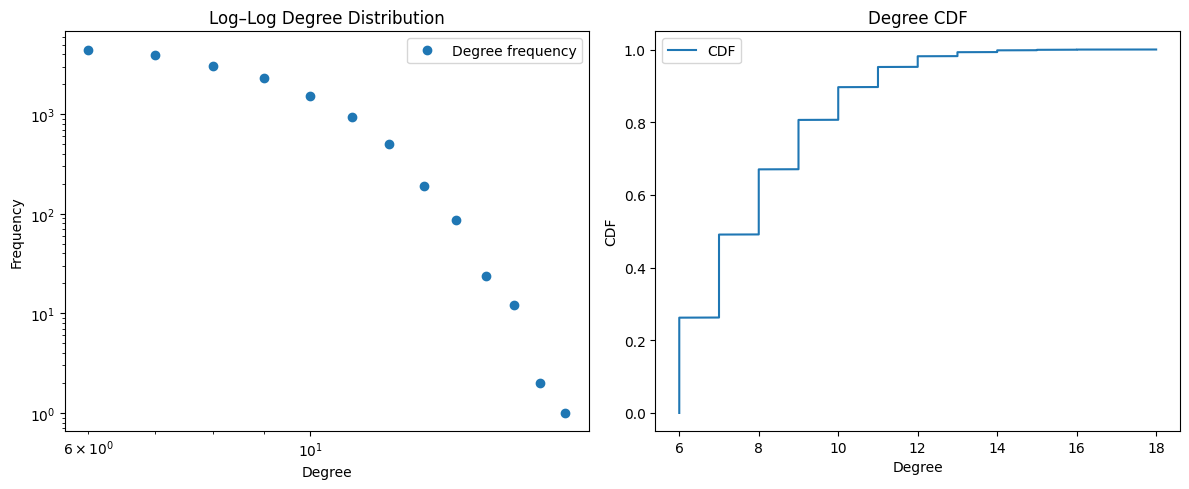

In [ ]:
# ------------------------------------------------------------------
# 1. LOG–LOG DEGREE + CDF SIDE BY SIDE (PUBLICATION STYLE)
# ------------------------------------------------------------------
unique_deg, counts = np.unique(degrees, return_counts=True)
sorted_deg = np.sort(degrees)
cdf = np.arange(1, len(sorted_deg)+1) / len(sorted_deg)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Log–log degree distribution
axes[0].loglog(unique_deg, counts, marker="o", linestyle="none", label="Degree frequency")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Log–Log Degree Distribution")
axes[0].legend()

# (b) CDF
axes[1].plot(sorted_deg, cdf, label="CDF")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("CDF")
axes[1].set_title("Degree CDF")
axes[1].legend()

plt.tight_layout()
save_fig(fig, "degree_loglog_cdf")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


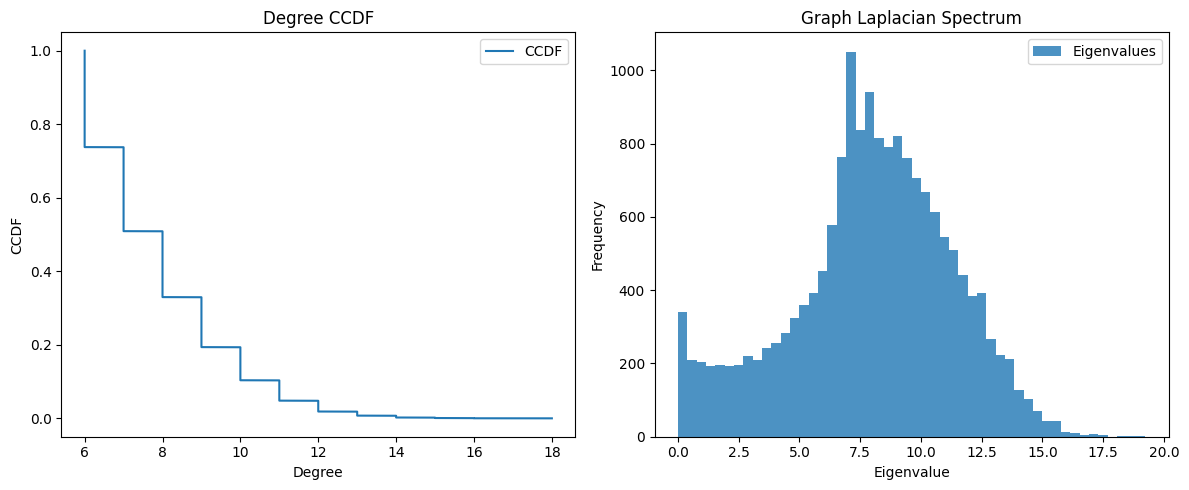

In [ ]:
# ------------------------------------------------------------------
# 2. CCDF + LAPLACIAN SPECTRUM SIDE BY SIDE
# ------------------------------------------------------------------
ccdf = 1 - cdf

# Laplacian spectrum
A = nx.adjacency_matrix(G).astype(float)
D = np.diag(np.ravel(np.array(A.sum(axis=1)).flatten()))
L = D - A.toarray()
eigs = np.linalg.eigvals(L)
eigs = np.real(eigs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) CCDF
axes[0].plot(sorted_deg, ccdf, label="CCDF")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("CCDF")
axes[0].set_title("Degree CCDF")
axes[0].legend()

# (b) Laplacian spectrum histogram
axes[1].hist(eigs, bins=50, alpha=0.8, label="Eigenvalues")
axes[1].set_xlabel("Eigenvalue")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Graph Laplacian Spectrum")
axes[1].legend()

plt.tight_layout()
save_fig(fig, "degree_ccdf_laplacian")
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


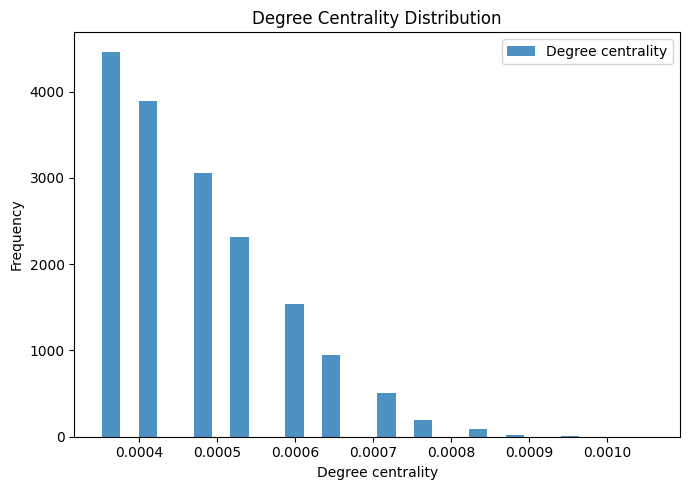

In [ ]:
# ------------------------------------------------------------------
# 3. DEGREE CENTRALITY DISTRIBUTION
# ------------------------------------------------------------------
centrality = nx.degree_centrality(G)
cent_vals = np.array(list(centrality.values()))

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(cent_vals, bins=30, alpha=0.8, label="Degree centrality")
ax.set_xlabel("Degree centrality")
ax.set_ylabel("Frequency")
ax.set_title("Degree Centrality Distribution")
ax.legend()
plt.tight_layout()
save_fig(fig, "degree_centrality_distribution")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


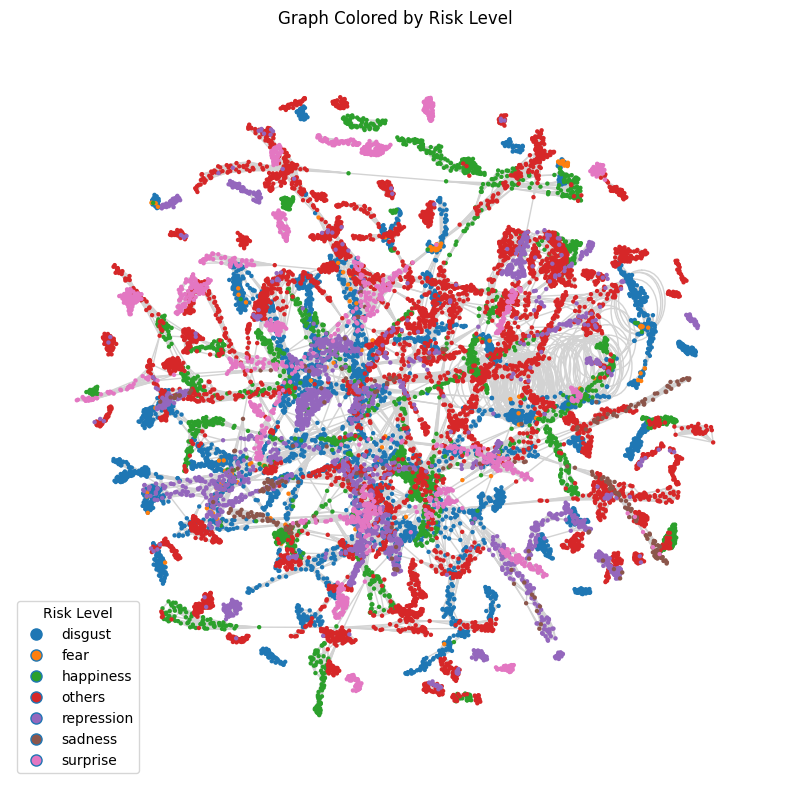

In [ ]:
# ------------------------------------------------------------------
# 4. GRAPH COLORED BY RISK LEVEL + LEGEND
# ------------------------------------------------------------------
# Adjust mapping if you have more than 7 classes
unique_labels = np.unique(y)
label_to_color = {
    0: 'tab:blue',
    1: 'tab:orange',
    2: 'tab:green',
    3: 'tab:red',
    4: 'tab:purple',
    5: 'tab:brown',
    6: 'tab:pink'
}
label_to_name = {
    0: "disgust",
    1: "fear",
    2: "happiness",
    3: "others",
    4: "repression",
    5: "sadness",
    6: "surprise"
}
node_colors = [label_to_color[label] for label in y]

pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw(
    G, pos,
    node_size=10,
    node_color=node_colors,
    edge_color="lightgray",
    linewidths=0,
    ax=ax
)
ax.set_title("Graph CASME II")
ax.axis("off")

# Build legend handles
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=label_to_color[lab], markersize=8)
    for lab in unique_labels
]
labels = [label_to_name[lab] for lab in unique_labels]
ax.legend(handles, labels, title="Risk Level",
          loc="lower left", bbox_to_anchor=(0.0, 0.0))
plt.tight_layout()
save_fig(fig, "graph_casme2")
plt.show()

C:\Users\Sad Bin Siddique\AppData\Local\Temp\ipykernel_26196\2012394044.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", num_comms)  # up to 10 distinct colors, cycles after that


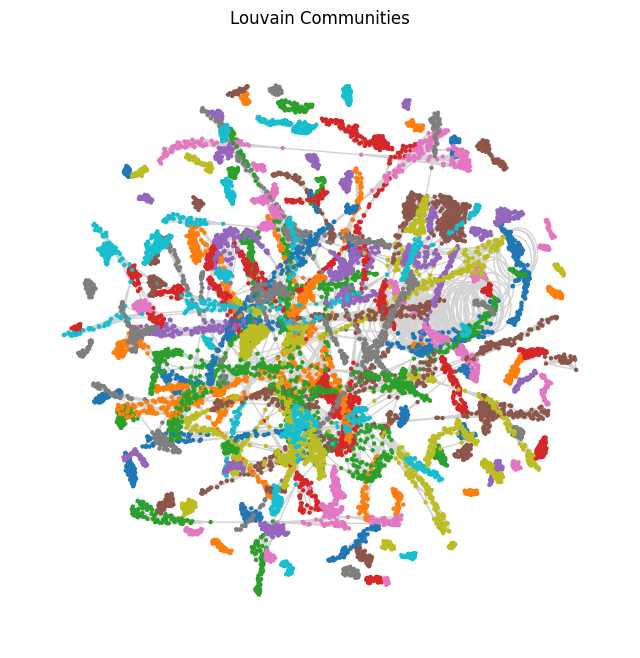

In [ ]:
# ------------------------------------------------------------------
# 5. LOUVAIN COMMUNITIES WITH MULTI-COLUMN LEGEND
# ------------------------------------------------------------------
communities = nx.algorithms.community.louvain_communities(G, seed=42)
comm_map = {}
for cid, comm in enumerate(communities):
    for node in comm:
        comm_map[node] = cid

# Assign colors via colormap
num_comms = len(communities)
cmap = plt.cm.get_cmap("tab10", num_comms)  # up to 10 distinct colors, cycles after that
node_comm_colors = [cmap(comm_map[n]) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw(
    G, pos,
    node_size=10,
    node_color=node_comm_colors,
    edge_color="lightgray",
    linewidths=0,
    ax=ax
)
ax.set_title("Louvain Communities")
ax.axis("off")

# Legend: multi-column if many communities
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=cmap(i), markersize=8)
    for i in range(num_comms)
]
labels = [f"Community {i}" for i in range(num_comms)]

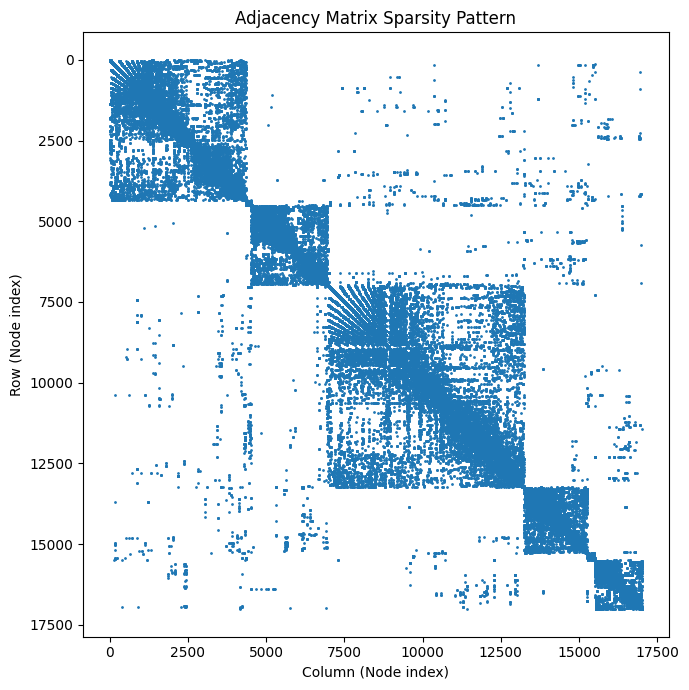

In [ ]:
# ------------------------------------------------------------------
# 6. ADJACENCY STRUCTURE (SPARSITY PATTERN)
# ------------------------------------------------------------------
# For large graphs, this is more efficient than dense imshow
row, col = A.nonzero()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(col, row, s=1)
ax.set_title("Adjacency Matrix Sparsity Pattern")
ax.set_xlabel("Column (Node index)")
ax.set_ylabel("Row (Node index)")
ax.invert_yaxis()
plt.tight_layout()
save_fig(fig, "adjacency_sparsity_pattern")
plt.show()

# CASME2: Feature Selection

In [ ]:
feature_columns = ['aspect_ratio', 'brightness',  'contrast', 'sharpness', 'edge_density', 'entropy', 'noise']
target_column = ['class']
# Compute feature-feature correlation matrix
corr = np.corrcoef(X_scaled, rowvar=False)   # shape: [F, F]

F = len(feature_columns)
threshold = 0.3   # you can tune this

G_feat = nx.Graph()
G_feat.add_nodes_from(feature_columns)

for i in range(F):
    for j in range(i+1, F):
        w = abs(corr[i, j])
        if w >= threshold:
            G_feat.add_edge(feature_columns[i], feature_columns[j], weight=w)

print("Feature graph:")
print("Nodes:", G_feat.number_of_nodes())
print("Edges:", G_feat.number_of_edges())

Feature graph:
Nodes: 7
Edges: 11


In [ ]:
import networkx as nx
import numpy as np


deg_dict = dict(G_feat.degree())
print("Degrees:", deg_dict)

# Use UNnormalized rich-club coefficient (no random rewiring, no error)
phi = nx.rich_club_coefficient(G_feat, normalized=False)

# Inspect values
for k in sorted(phi.keys()):
    print(f"k = {k}, phi(k) = {phi[k]:.3f}")

# Choose k* as the k with maximum rich-club coefficient among k>=1
valid_k = [k for k in phi.keys() if k >= 1 and not np.isnan(phi[k])]
k_star = max(valid_k, key=lambda k: phi[k])

print("Chosen k* =", k_star, "with phi(k*) =", phi[k_star])

# Select features with degree >= k*
selected_features = [feat for feat, d in deg_dict.items() if d >= k_star]

print("\nSelected features (unnormalized):")
for f in selected_features:
    print("  -", f)

# Reduced feature matrix
X_selected = df[selected_features].values

Degrees: {'aspect_ratio': 2, 'brightness': 3, 'contrast': 4, 'sharpness': 3, 'edge_density': 2, 'entropy': 3, 'noise': 5}
k = 0, phi(k) = 0.524
k = 1, phi(k) = 0.524
k = 2, phi(k) = 0.700
k = 3, phi(k) = 1.000
Chosen k* = 3 with phi(k*) = 1.0

Selected features (unnormalized):
  - brightness
  - contrast
  - sharpness
  - entropy
  - noise


In [ ]:
selected_features

['brightness', 'contrast', 'sharpness', 'entropy', 'noise']

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [ ]:
target_col = 'class'  # Replace with your actual target column name
X = df[selected_features].values
y = df[target_col].values

print("Selected features:", selected_features)
print("X shape:", X.shape, "| y shape:", y.shape)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Selected features: ['brightness', 'contrast', 'sharpness', 'entropy', 'noise']
X shape: (17019, 5) | y shape: (17019,)


In [ ]:
from sklearn.neighbors import NearestNeighbors

k = 6  # For facial patches/landmarks in CASME II, keep k small (e.g., 4 to 8)
nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

edges = []
N = X_scaled.shape[0]

for i in range(N):
    for j in indices[i][1:]:  # skip self (indices[i][0])
        edges.append([i, j])
        edges.append([j, i])  # undirected

edge_index = np.array(edges).T  # shape [2, E]
print("edge_index shape:", edge_index.shape)

edge_index shape: (2, 204228)


In [ ]:
import torch
from torch_geometric.data import Data

x = torch.tensor(X_scaled, dtype=torch.float32)       # [N, F_sel]

# FIX: Changed 'y' to 'y_encoded' so PyTorch gets integers instead of strings
y_tensor = torch.tensor(y_encoded, dtype=torch.long)  # [N]

edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)

data = Data(x=x, edge_index=edge_index_tensor, y=y_tensor)
print(data)

Data(x=[17019, 5], edge_index=[2, 204228], y=[17019])


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import torch

num_nodes = data.num_nodes
all_idx = np.arange(num_nodes)

# FIX: Replaced 'y' with 'y_encoded' 
train_idx, temp_idx, y_train, y_temp = train_test_split(
    all_idx, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded
)

# Split the temp data into validation and test sets
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Initialize masks
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

# Apply indices to masks
train_mask[train_idx] = True
val_mask[val_idx]     = True
test_mask[test_idx]   = True

# Attach masks to the PyG Data object
data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

print("Train nodes:", train_mask.sum().item())
print("Val nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

Train nodes: 10211
Val nodes: 3404
Test nodes: 3404


## GCN Conv

In [ ]:
num_features = data.num_node_features
num_classes = int(y_tensor.max().item() + 1)  # works if labels are 0..C-1

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin   = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.lin(x)
        return x

model = GCN(in_channels=num_features,
            hidden_channels=64,
            out_channels=num_classes)

print(model)

GCN(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=7, bias=True)
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

def accuracy(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out[mask].argmax(dim=1)
        correct = (preds == data.y[mask]).sum().item()
        total = int(mask.sum().item())
        return correct / total if total > 0 else 0.0

for epoch in range(1, 1001):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        train_acc = accuracy(data.train_mask)
        val_acc = accuracy(data.val_mask)
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} "
              f"| Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 020 | Loss: 1.7267 | Train Acc: 0.4080 | Val Acc: 0.4063
Epoch 040 | Loss: 1.5124 | Train Acc: 0.4062 | Val Acc: 0.4031
Epoch 060 | Loss: 1.4264 | Train Acc: 0.4074 | Val Acc: 0.3981
Epoch 080 | Loss: 1.3873 | Train Acc: 0.4218 | Val Acc: 0.4101
Epoch 100 | Loss: 1.3553 | Train Acc: 0.4381 | Val Acc: 0.4263
Epoch 120 | Loss: 1.3225 | Train Acc: 0.4645 | Val Acc: 0.4492
Epoch 140 | Loss: 1.2878 | Train Acc: 0.4850 | Val Acc: 0.4727
Epoch 160 | Loss: 1.2520 | Train Acc: 0.4858 | Val Acc: 0.4783
Epoch 180 | Loss: 1.2156 | Train Acc: 0.4956 | Val Acc: 0.4850
Epoch 200 | Loss: 1.1788 | Train Acc: 0.5056 | Val Acc: 0.4950
Epoch 220 | Loss: 1.1422 | Train Acc: 0.5230 | Val Acc: 0.5162
Epoch 240 | Loss: 1.1054 | Train Acc: 0.5546 | Val Acc: 0.5538
Epoch 260 | Loss: 1.0680 | Train Acc: 0.5777 | Val Acc: 0.5778
Epoch 280 | Loss: 1.0298 | Train Acc: 0.6081 | Val Acc: 0.6128
Epoch 300 | Loss: 0.9897 | Train Acc: 0.6266 | Val Acc: 0.6313
Epoch 320 | Loss: 0.9487 | Train Acc: 0.6439 | Val Acc:

In [ ]:
test_acc = accuracy(data.test_mask)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8992


## Graph SAGE

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)      # default = "mean" aggregator
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.lin   = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Final classification layer
        x = self.lin(x)
        return x

In [ ]:
num_features = data.num_node_features
num_classes = int(data.y.max().item() + 1)

model = GraphSAGE(
    in_channels=num_features,
    hidden_channels=64,
    out_channels=num_classes,
    dropout=0.3,
)
print(model)

GraphSAGE(
  (conv1): SAGEConv(5, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (lin): Linear(in_features=64, out_features=7, bias=True)
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

def accuracy(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out[mask].argmax(dim=1)
        correct = (preds == data.y[mask]).sum().item()
        total = int(mask.sum().item())
        return correct / total if total > 0 else 0.0

for epoch in range(1, 1001):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        train_acc = accuracy(data.train_mask)
        val_acc = accuracy(data.val_mask)
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} "
              f"| Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

test_acc = accuracy(data.test_mask)
print(f"Test Accuracy (GraphSAGE): {test_acc:.4f}")

Epoch 020 | Loss: 1.5219 | Train Acc: 0.4099 | Val Acc: 0.4051
Epoch 040 | Loss: 1.4181 | Train Acc: 0.4508 | Val Acc: 0.4348
Epoch 060 | Loss: 1.3621 | Train Acc: 0.4811 | Val Acc: 0.4706
Epoch 080 | Loss: 1.3147 | Train Acc: 0.5056 | Val Acc: 0.4950
Epoch 100 | Loss: 1.2659 | Train Acc: 0.5043 | Val Acc: 0.4971
Epoch 120 | Loss: 1.2329 | Train Acc: 0.5128 | Val Acc: 0.5041
Epoch 140 | Loss: 1.1928 | Train Acc: 0.5224 | Val Acc: 0.5185
Epoch 160 | Loss: 1.1524 | Train Acc: 0.5433 | Val Acc: 0.5432
Epoch 180 | Loss: 1.1227 | Train Acc: 0.5549 | Val Acc: 0.5576
Epoch 200 | Loss: 1.0906 | Train Acc: 0.5664 | Val Acc: 0.5723
Epoch 220 | Loss: 1.0650 | Train Acc: 0.5839 | Val Acc: 0.5949
Epoch 240 | Loss: 1.0428 | Train Acc: 0.6061 | Val Acc: 0.6202
Epoch 260 | Loss: 1.0145 | Train Acc: 0.6284 | Val Acc: 0.6442
Epoch 280 | Loss: 0.9937 | Train Acc: 0.6587 | Val Acc: 0.6689
Epoch 300 | Loss: 0.9812 | Train Acc: 0.6763 | Val Acc: 0.6827
Epoch 320 | Loss: 0.9560 | Train Acc: 0.6861 | Val Acc:

## Gin

In [ ]:
from torch_geometric.nn import GINConv

class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super().__init__()

        # GIN layer 1
        nn1 = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
        )
        self.conv1 = GINConv(nn1, train_eps=True)

        # GIN layer 2
        nn2 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
        )
        self.conv2 = GINConv(nn2, train_eps=True)

        # GIN layer 3
        nn3 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
        )
        self.conv3 = GINConv(nn3, train_eps=True)

        # Final classifier
        self.lin = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.lin(x)
        return x

In [ ]:
num_features = data.num_node_features
num_classes = int(data.y.max().item() + 1)

model = GIN(
    in_channels=num_features,
    hidden_channels=64,
    out_channels=num_classes,
    dropout=0.3,
)
print(model)

GIN(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  ))
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  ))
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  ))
  (lin): Linear(in_features=64, out_features=7, bias=True)
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

def accuracy(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out[mask].argmax(dim=1)
        correct = (preds == data.y[mask]).sum().item()
        total = int(mask.sum().item())
        return correct / total if total > 0 else 0.0

for epoch in range(1, 1001):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        train_acc = accuracy(data.train_mask)
        val_acc = accuracy(data.val_mask)
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} "
              f"| Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

test_acc = accuracy(data.test_mask)
print(f"Test Accuracy (GIN): {test_acc:.4f}")

Epoch 020 | Loss: 1.5046 | Train Acc: 0.4697 | Val Acc: 0.4686
Epoch 040 | Loss: 1.3201 | Train Acc: 0.5761 | Val Acc: 0.5799
Epoch 060 | Loss: 1.1354 | Train Acc: 0.6429 | Val Acc: 0.6489
Epoch 080 | Loss: 1.0241 | Train Acc: 0.7097 | Val Acc: 0.7121
Epoch 100 | Loss: 0.9198 | Train Acc: 0.7542 | Val Acc: 0.7562
Epoch 120 | Loss: 0.7802 | Train Acc: 0.7909 | Val Acc: 0.7867
Epoch 140 | Loss: 0.7067 | Train Acc: 0.8237 | Val Acc: 0.8226
Epoch 160 | Loss: 0.6117 | Train Acc: 0.8460 | Val Acc: 0.8399
Epoch 180 | Loss: 0.5466 | Train Acc: 0.8603 | Val Acc: 0.8587
Epoch 200 | Loss: 0.4870 | Train Acc: 0.8886 | Val Acc: 0.8796
Epoch 220 | Loss: 0.4288 | Train Acc: 0.8973 | Val Acc: 0.8972
Epoch 240 | Loss: 0.3883 | Train Acc: 0.9116 | Val Acc: 0.9078
Epoch 260 | Loss: 0.3672 | Train Acc: 0.9158 | Val Acc: 0.9095
Epoch 280 | Loss: 0.3595 | Train Acc: 0.9197 | Val Acc: 0.9139
Epoch 300 | Loss: 0.3306 | Train Acc: 0.9285 | Val Acc: 0.9274
Epoch 320 | Loss: 0.3005 | Train Acc: 0.9331 | Val Acc:

# GAT

In [ ]:
from torch_geometric.nn import GATConv

class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 heads=8, dropout=0.3):
        super().__init__()

        # First GAT layer: multi-head
        self.gat1 = GATConv(
            in_channels,
            hidden_channels,
            heads=heads,
            dropout=dropout,
            concat=True  # output dim = hidden_channels * heads
        )

        # Second GAT layer: single-head to output classes
        self.gat2 = GATConv(
            hidden_channels * heads,
            out_channels,
            heads=1,
            dropout=dropout,
            concat=False  # output dim = out_channels
        )

        self.dropout = dropout

    def forward(self, x, edge_index):
        # Layer 1
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2
        x = self.gat2(x, edge_index)
        # No activation here; CrossEntropyLoss expects raw logits
        return x

In [ ]:
num_features = data.num_node_features
num_classes = int(data.y.max().item() + 1)

model = GAT(
    in_channels=num_features,
    hidden_channels=8,   # per-head; total after layer1 = 8 * heads
    out_channels=num_classes,
    heads=8,
    dropout=0.3,
)
print(model)

GAT(
  (gat1): GATConv(5, 8, heads=8)
  (gat2): GATConv(64, 7, heads=1)
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

def accuracy(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out[mask].argmax(dim=1)
        correct = (preds == data.y[mask]).sum().item()
        total = int(mask.sum().item())
        return correct / total if total > 0 else 0.0

for epoch in range(1, 1001):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        train_acc = accuracy(data.train_mask)
        val_acc = accuracy(data.val_mask)
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} "
              f"| Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

test_acc = accuracy(data.test_mask)
print(f"Test Accuracy (GAT): {test_acc:.4f}")

Epoch 020 | Loss: 1.8159 | Train Acc: 0.3585 | Val Acc: 0.3522
Epoch 040 | Loss: 1.6977 | Train Acc: 0.3815 | Val Acc: 0.3743
Epoch 060 | Loss: 1.6252 | Train Acc: 0.3831 | Val Acc: 0.3751
Epoch 080 | Loss: 1.5676 | Train Acc: 0.3753 | Val Acc: 0.3684
Epoch 100 | Loss: 1.5264 | Train Acc: 0.3777 | Val Acc: 0.3675
Epoch 120 | Loss: 1.5024 | Train Acc: 0.3798 | Val Acc: 0.3716
Epoch 140 | Loss: 1.4740 | Train Acc: 0.3757 | Val Acc: 0.3681
Epoch 160 | Loss: 1.4657 | Train Acc: 0.3768 | Val Acc: 0.3702
Epoch 180 | Loss: 1.4580 | Train Acc: 0.3815 | Val Acc: 0.3743
Epoch 200 | Loss: 1.4496 | Train Acc: 0.3815 | Val Acc: 0.3754
Epoch 220 | Loss: 1.4480 | Train Acc: 0.3847 | Val Acc: 0.3784
Epoch 240 | Loss: 1.4313 | Train Acc: 0.3886 | Val Acc: 0.3819
Epoch 260 | Loss: 1.4265 | Train Acc: 0.3902 | Val Acc: 0.3834
Epoch 280 | Loss: 1.4287 | Train Acc: 0.3944 | Val Acc: 0.3866
Epoch 300 | Loss: 1.4270 | Train Acc: 0.4039 | Val Acc: 0.3939
Epoch 320 | Loss: 1.4175 | Train Acc: 0.4088 | Val Acc:

## Graph Swarm Neural Network

In [ ]:
from torch_geometric.nn import GCNConv

class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin   = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin(x)
        return x

In [ ]:
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

def evaluate_hyperparams(hidden_dim, lr, dropout, epochs=50):
    hidden_dim = int(hidden_dim)

    model = GCN(
        in_channels=num_features,
        hidden_channels=hidden_dim,
        out_channels=num_classes,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()

    # Train for a few epochs (quick evaluation)
    for ep in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    # Compute validation accuracy
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out[data.val_mask].argmax(dim=1)
        correct = (preds == data.y[data.val_mask]).sum().item()
        total = int(data.val_mask.sum().item())
        val_acc = correct / total if total > 0 else 0.0

    # Fitness to minimize
    return 1.0 - val_acc

In [ ]:
def clip_params(pos, bounds):
    """Clip each dimension of pos to [low, high]."""
    clipped = np.empty_like(pos)
    for i, (low, high) in enumerate(bounds):
        clipped[i] = np.clip(pos[i], low, high)
    return clipped

# Bounds: [hidden_dim, lr, dropout]
bounds = [
    (16, 256),        # hidden_dim
    (1e-4, 1e-2),     # learning rate
    (0.0, 0.6),       # dropout
]

num_particles = 10
num_iters = 15

# Initialize particles randomly within bounds
dim = 3
positions = np.zeros((num_particles, dim))
velocities = np.zeros((num_particles, dim))

for i in range(num_particles):
    for d in range(dim):
        low, high = bounds[d]
        positions[i, d] = np.random.uniform(low, high)
        velocities[i, d] = 0.0

# PSO hyperparams
w = 0.7      # inertia
c1 = 1.4     # cognitive
c2 = 1.4     # social

# Personal and global bests
pbest_pos = positions.copy()
pbest_val = np.full(num_particles, np.inf)

gbest_pos = None
gbest_val = np.inf

for it in range(num_iters):
    print(f"\n=== PSO Iteration {it+1}/{num_iters} ===")

    for i in range(num_particles):
        # Clip current position into bounds
        positions[i] = clip_params(positions[i], bounds)

        hidden_dim, lr, dropout = positions[i]
        fit = evaluate_hyperparams(hidden_dim, lr, dropout, epochs=30)

        # Update personal best
        if fit < pbest_val[i]:
            pbest_val[i] = fit
            pbest_pos[i] = positions[i].copy()

        # Update global best
        if fit < gbest_val:
            gbest_val = fit
            gbest_pos = positions[i].copy()

        print(f"Particle {i}: fitness={fit:.4f}, params={positions[i]}")

    # Update velocities and positions
    for i in range(num_particles):
        r1 = np.random.rand(dim)
        r2 = np.random.rand(dim)

        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (pbest_pos[i] - positions[i])
            + c2 * r2 * (gbest_pos - positions[i])
        )
        positions[i] += velocities[i]

print("\nBest fitness (1 - val_acc):", gbest_val)
print("Best hyperparameters (hidden_dim, lr, dropout):", gbest_pos)



=== PSO Iteration 1/15 ===
Particle 0: fitness=0.5729, params=[3.83541696e+01 6.33353003e-03 5.56962791e-01]
Particle 1: fitness=0.5400, params=[1.55419140e+02 2.91688085e-03 1.12473333e-01]
Particle 2: fitness=0.5138, params=[1.23325965e+02 7.70338536e-03 4.69562240e-01]
Particle 3: fitness=0.5564, params=[5.61309036e+01 5.50241840e-03 4.64789262e-01]
Particle 4: fitness=0.5238, params=[1.70313993e+02 5.39975384e-03 3.26315115e-01]
Particle 5: fitness=0.5226, params=[7.88351796e+01 9.00195292e-03 3.35999082e-01]
Particle 6: fitness=0.5188, params=[2.09949827e+02 6.09116984e-03 8.60282666e-02]
Particle 7: fitness=0.5297, params=[8.43350748e+01 7.09817025e-03 5.28977263e-01]
Particle 8: fitness=0.4935, params=[2.26921741e+02 7.71346892e-03 4.71133523e-01]
Particle 9: fitness=0.5185, params=[1.48769974e+02 4.56104875e-03 3.69020855e-01]

=== PSO Iteration 2/15 ===
Particle 0: fitness=0.5185, params=[9.28980716e+01 7.76333664e-03 5.19131890e-01]
Particle 1: fitness=0.4979, params=[1.9325

In [ ]:
best_hidden, best_lr, best_dropout = gbest_pos
best_hidden = int(best_hidden)

print(f"Using PSO-optimized GNN: hidden={best_hidden}, lr={best_lr:.5f}, dropout={best_dropout:.3f}")

model = GCN(
    in_channels=num_features,
    hidden_channels=best_hidden,
    out_channels=num_classes,
    dropout=best_dropout
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

def accuracy(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out[mask].argmax(dim=1)
        correct = (preds == data.y[mask]).sum().item()
        total = int(mask.sum().item())
        return correct / total if total > 0 else 0.0

# Full training
for epoch in range(1, 201):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        train_acc = accuracy(data.train_mask)
        val_acc = accuracy(data.val_mask)
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

test_acc = accuracy(data.test_mask)
print(f"\nTest Accuracy (Graph Swarm GNN with PSO-tuned GCN): {test_acc:.4f}")


Using PSO-optimized GNN: hidden=256, lr=0.01000, dropout=0.059
Epoch 020 | Loss: 1.2372 | Train Acc: 0.5028 | Val Acc: 0.5003
Epoch 040 | Loss: 0.9006 | Train Acc: 0.6084 | Val Acc: 0.6143
Epoch 060 | Loss: 0.7124 | Train Acc: 0.7374 | Val Acc: 0.7382
Epoch 080 | Loss: 0.5881 | Train Acc: 0.7943 | Val Acc: 0.7929
Epoch 100 | Loss: 0.5124 | Train Acc: 0.8232 | Val Acc: 0.8140
Epoch 120 | Loss: 0.4433 | Train Acc: 0.8642 | Val Acc: 0.8616
Epoch 140 | Loss: 0.4078 | Train Acc: 0.8728 | Val Acc: 0.8634
Epoch 160 | Loss: 0.3887 | Train Acc: 0.8717 | Val Acc: 0.8652
Epoch 180 | Loss: 0.3355 | Train Acc: 0.9052 | Val Acc: 0.9051
Epoch 200 | Loss: 0.3236 | Train Acc: 0.9144 | Val Acc: 0.9051

Test Accuracy (Graph Swarm GNN with PSO-tuned GCN): 0.9183


# ChebNet

In [ ]:
class ChebNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 K=3, dropout=0.3):
        super().__init__()
        # First Chebyshev convolution
        self.conv1 = ChebConv(in_channels, hidden_channels, K=K)
        # Second Chebyshev convolution
        self.conv2 = ChebConv(hidden_channels, hidden_channels, K=K)
        # Final classifier
        self.lin = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Class logits
        x = self.lin(x)
        return x


In [ ]:
from torch_geometric.nn import ChebConv

num_features = data.num_node_features
num_classes = int(data.y.max().item() + 1)

model = ChebNet(
    in_channels=num_features,
    hidden_channels=64,
    out_channels=num_classes,
    K=3,          # Chebyshev polynomial order
    dropout=0.3,
)
print(model)


ChebNet(
  (conv1): ChebConv(5, 64, K=3, normalization=sym)
  (conv2): ChebConv(64, 64, K=3, normalization=sym)
  (lin): Linear(in_features=64, out_features=7, bias=True)
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

def accuracy(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = out[mask].argmax(dim=1)
        correct = (preds == data.y[mask]).sum().item()
        total = int(mask.sum().item())
        return correct / total if total > 0 else 0.0

for epoch in range(1, 1001):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        train_acc = accuracy(data.train_mask)
        val_acc = accuracy(data.val_mask)
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} "
              f"| Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

test_acc = accuracy(data.test_mask)
print(f"Test Accuracy (ChebNet): {test_acc:.4f}")

Epoch 020 | Loss: 1.5353 | Train Acc: 0.3912 | Val Acc: 0.3907
Epoch 040 | Loss: 1.4424 | Train Acc: 0.4490 | Val Acc: 0.4354
Epoch 060 | Loss: 1.3783 | Train Acc: 0.4633 | Val Acc: 0.4533
Epoch 080 | Loss: 1.3358 | Train Acc: 0.4875 | Val Acc: 0.4777
Epoch 100 | Loss: 1.2866 | Train Acc: 0.4976 | Val Acc: 0.4927
Epoch 120 | Loss: 1.2470 | Train Acc: 0.5080 | Val Acc: 0.5053
Epoch 140 | Loss: 1.2109 | Train Acc: 0.5208 | Val Acc: 0.5165
Epoch 160 | Loss: 1.1679 | Train Acc: 0.5426 | Val Acc: 0.5417
Epoch 180 | Loss: 1.1297 | Train Acc: 0.5588 | Val Acc: 0.5614
Epoch 200 | Loss: 1.0978 | Train Acc: 0.5853 | Val Acc: 0.5884
Epoch 220 | Loss: 1.0639 | Train Acc: 0.6036 | Val Acc: 0.6061
Epoch 240 | Loss: 1.0349 | Train Acc: 0.6180 | Val Acc: 0.6260
Epoch 260 | Loss: 1.0084 | Train Acc: 0.6373 | Val Acc: 0.6419
Epoch 280 | Loss: 0.9710 | Train Acc: 0.6714 | Val Acc: 0.6763
Epoch 300 | Loss: 0.9490 | Train Acc: 0.6833 | Val Acc: 0.6877
Epoch 320 | Loss: 0.9172 | Train Acc: 0.7044 | Val Acc: